# Helicopter Accelerometer  EDA Pipeline
Each row = 1 minute of 1024 Hz data (61,440 timepoints). Labels: 1 = anomaly, 0 = normal.

In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats, signal
from scipy.fft import fft, fftfreq
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='darkgrid', palette='muted')
FS = 1024  # Hz
DURATION = 60  # seconds
N = FS * DURATION  # 61440 samples per row

In [61]:
# DATA LOADING
BASE_PATH = "/kaggle/input/datasets/nagasai524/anomaly-detection-in-helicopter/"

train_df = pd.read_csv(BASE_PATH + "train_df.csv", header=None, skiprows=1, index_col=0)
validation_df = pd.read_csv(BASE_PATH + "validation_df.csv", header=None, skiprows=1, index_col=0)
groundtruth_df = pd.read_csv(BASE_PATH + "dfvalid_groundtruth.csv")

X_train_raw = train_df.values.astype(np.float32)
X_test_raw  = validation_df.values.astype(np.float32)
y_test      = groundtruth_df["anomaly"].values.astype(int)

print(f"X_train shape : {X_train_raw.shape}")
print(f"X_test  shape : {X_test_raw.shape}")
print(f"y_test  shape : {y_test.shape}")
print(f"Anomaly rate  : {y_test.mean()*100:.1f}% ({y_test.sum()} / {len(y_test)})")

X_train shape : (1677, 61440)
X_test  shape : (594, 61440)
y_test  shape : (594,)
Anomaly rate  : 50.0% (297 / 594)


## 1  Dataset Overview

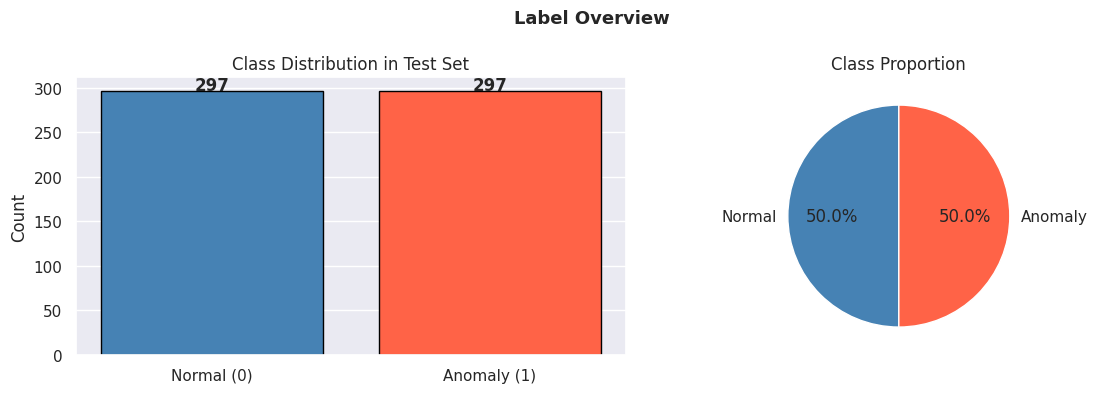

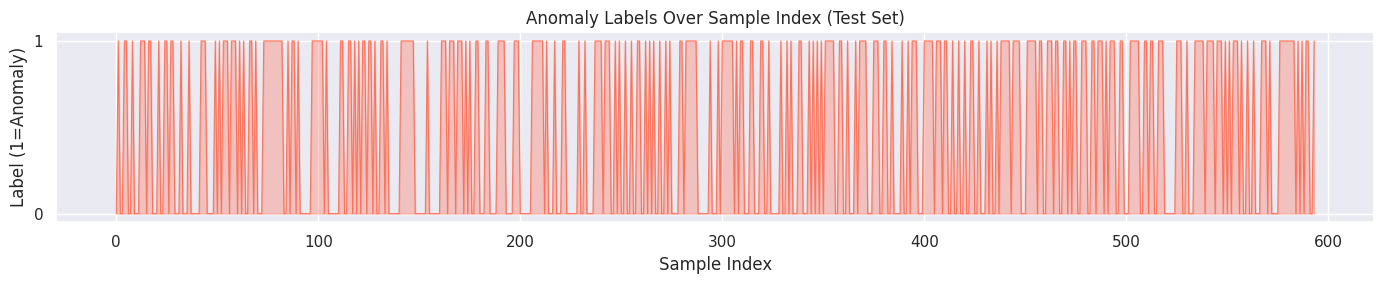

In [62]:
# SECTION 1: DATASET OVERVIEW

# --- 1a. Class distribution ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = pd.Series(y_test).value_counts().sort_index()
axes[0].bar(['Normal (0)', 'Anomaly (1)'], counts.values, color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_title('Class Distribution in Test Set')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 0.5, str(v), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=['Normal', 'Anomaly'], autopct='%1.1f%%',
            colors=['steelblue', 'tomato'], startangle=90)
axes[1].set_title('Class Proportion')
plt.suptitle('Label Overview', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# --- 1b. Anomaly label distribution over time (sequential order) ---
plt.figure(figsize=(14, 3))
plt.plot(y_test, color='tomato', linewidth=0.8, alpha=0.8)
plt.fill_between(range(len(y_test)), y_test, alpha=0.3, color='tomato')
plt.title('Anomaly Labels Over Sample Index (Test Set)')
plt.xlabel('Sample Index')
plt.ylabel('Label (1=Anomaly)')
plt.yticks([0, 1])
plt.tight_layout()
plt.show()

## 2  Statistical Summaries

In [63]:
# SECTION 2: STATISTICAL FEATURE EXTRACTION

def extract_stats(X):
    """Extract time-domain statistical features per row (sample)."""
    df = pd.DataFrame({
        'mean'      : X.mean(axis=1),
        'std'       : X.std(axis=1),
        'rms'       : np.sqrt((X**2).mean(axis=1)),
        'min'       : X.min(axis=1),
        'max'       : X.max(axis=1),
        'peak2peak' : X.max(axis=1) - X.min(axis=1),
        'skewness'  : stats.skew(X, axis=1),
        'kurtosis'  : stats.kurtosis(X, axis=1),
        'crest_factor': np.abs(X).max(axis=1) / (np.sqrt((X**2).mean(axis=1)) + 1e-9),
    })
    return df

stats_train = extract_stats(X_train_raw)
stats_test  = extract_stats(X_test_raw)
stats_test['label'] = y_test

print("=== Train Statistical Features ===")
display(stats_train.describe().round(4))

print("\n=== Test Statistical Features (Normal) ===")
display(stats_test[stats_test.label==0].drop('label',axis=1).describe().round(4))

print("\n=== Test Statistical Features (Anomaly) ===")
display(stats_test[stats_test.label==1].drop('label',axis=1).describe().round(4))

=== Train Statistical Features ===


,mean,std,rms,min,max,peak2peak,skewness,kurtosis,crest_factor
count,1677.0000,1677.0000,1677.0000,1677.0000,1677.0000,1677.0000,1677.0000,1677.0000,1677.0000
mean,0.0100,0.6355,0.6464,-2.4278,2.4327,4.8605,-0.0021,0.1011,4.3281
std,0.1234,0.6527,0.6537,2.3384,2.2058,4.5087,0.2491,1.4403,1.3531
min,-0.6477,0.0131,0.0320,-19.0723,0.1281,0.1333,-3.6905,-1.4772,1.7399
25%,-0.0215,0.1803,0.1878,-3.2055,0.8243,1.6225,-0.0894,-0.4083,3.5918
50%,0.0006,0.4995,0.5139,-1.9231,1.9349,3.8668,0.0025,-0.1039,4.1191
75%,0.0193,0.8676,0.8782,-0.7783,3.2761,6.5833,0.0924,0.1905,4.6914
max,1.0283,6.8130,6.8130,-0.0025,17.9149,36.9872,1.1808,22.1009,20.5630



=== Test Statistical Features (Normal) ===


,mean,std,rms,min,max,peak2peak,skewness,kurtosis,crest_factor
count,297.0000,297.0000,297.0000,297.0000,297.0000,297.0000,297.0000,297.0000,297.0000
mean,-0.0048,0.3571,0.3588,-1.3797,1.3962,2.7759,-0.0056,-0.0577,4.3585
std,0.0401,0.2612,0.2619,1.0376,0.9805,2.0004,0.1624,0.8503,1.5026
min,-0.2089,0.0352,0.0352,-4.8912,0.1411,0.2873,-0.5308,-1.4072,2.0465
25%,-0.0126,0.1626,0.1645,-1.8566,0.6887,1.3572,-0.0617,-0.5055,3.6143
50%,0.0002,0.2463,0.2513,-1.0164,1.0434,2.0885,0.0014,-0.0995,4.1457
75%,0.0165,0.5373,0.5375,-0.6633,1.9030,3.7968,0.0676,0.1334,4.6453
max,0.0848,1.2751,1.2760,-0.1461,4.6184,9.5084,0.6870,6.0859,16.2637



=== Test Statistical Features (Anomaly) ===


,mean,std,rms,min,max,peak2peak,skewness,kurtosis,crest_factor
count,297.0000,297.0000,297.0000,297.0000,297.0000,297.0000,296.0000,296.0000,297.0000
mean,-7.0336,1.0444,7.8612,-12.9334,-4.0737,8.8597,-0.3569,0.7706,3.6302
std,10.6351,1.4195,10.1902,10.8996,11.9692,10.3907,0.8620,3.0185,2.3691
min,-32.7558,0.0000,0.0000,-35.7424,-32.6922,0.0000,-4.5592,-1.9992,0.0000
25%,-10.0251,0.0435,1.0668,-20.4310,-8.7672,0.3281,-0.7883,-0.5666,1.0611
50%,-2.0268,0.5427,2.8607,-10.7197,0.9623,4.9597,-0.3114,0.1309,3.5971
75%,-0.5974,1.5058,10.9308,-4.5354,3.3635,14.1591,0.0662,1.1927,5.0835
max,10.4894,12.3941,32.7617,9.7148,11.1994,41.0574,1.7065,29.5080,14.1377


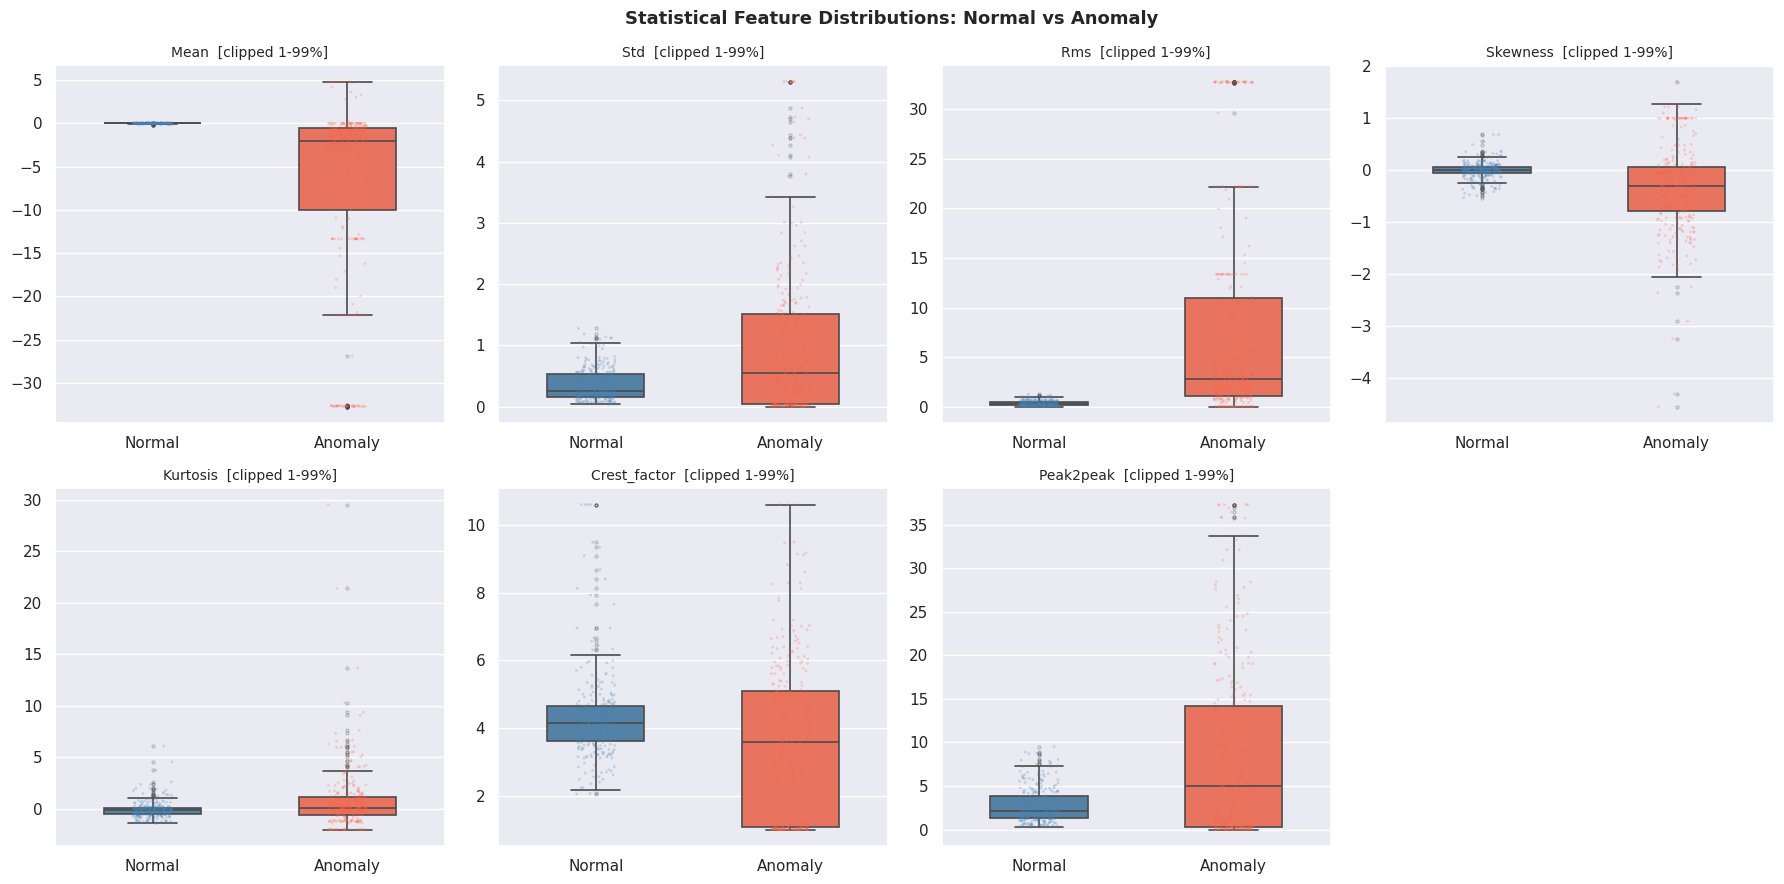

Skewness breakdown:
       count    mean     std     min     25%     50%     75%     max
label                                                               
0      297.0 -0.0056  0.1624 -0.5308 -0.0617  0.0014  0.0676  0.6870
1      296.0 -0.3569  0.8620 -4.5592 -0.7883 -0.3114  0.0662  1.7065


In [64]:
# --- Box plots: feature distributions by class ---
features = ['mean','std','rms','skewness','kurtosis','crest_factor','peak2peak']
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

plot_df = stats_test[features + ['label']].copy()
plot_df['Class'] = plot_df['label'].map({0:'Normal', 1:'Anomaly'})

for i, feat in enumerate(features):
    ax = axes[i]
    
    # Clip to 1st-99th percentile to prevent outlier-driven axis squashing
    lo, hi = np.percentile(plot_df[feat], [1, 99])
    clipped = plot_df.copy()
    clipped[feat] = clipped[feat].clip(lo, hi)
    
    sns.boxplot(data=clipped, x='Class', y=feat, ax=ax,
                palette={'Normal':'steelblue','Anomaly':'tomato'},
                order=['Normal','Anomaly'],
                width=0.5, linewidth=1.2,
                flierprops=dict(marker='o', markersize=2, alpha=0.3))
    
    # Overlay individual points so sparse classes are visible
    sns.stripplot(data=clipped, x='Class', y=feat, ax=ax,
                  palette={'Normal':'steelblue','Anomaly':'tomato'},
                  order=['Normal','Anomaly'],
                  size=2, alpha=0.25, jitter=True)
    
    ax.set_title(f'{feat.capitalize()}  [clipped 1-99%]', fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel("")

axes[-1].axis('off')
plt.suptitle('Statistical Feature Distributions: Normal vs Anomaly', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Explicit skewness stats for inspection
print("Skewness breakdown:")
print(stats_test.groupby("label")["skewness"].describe().round(4))


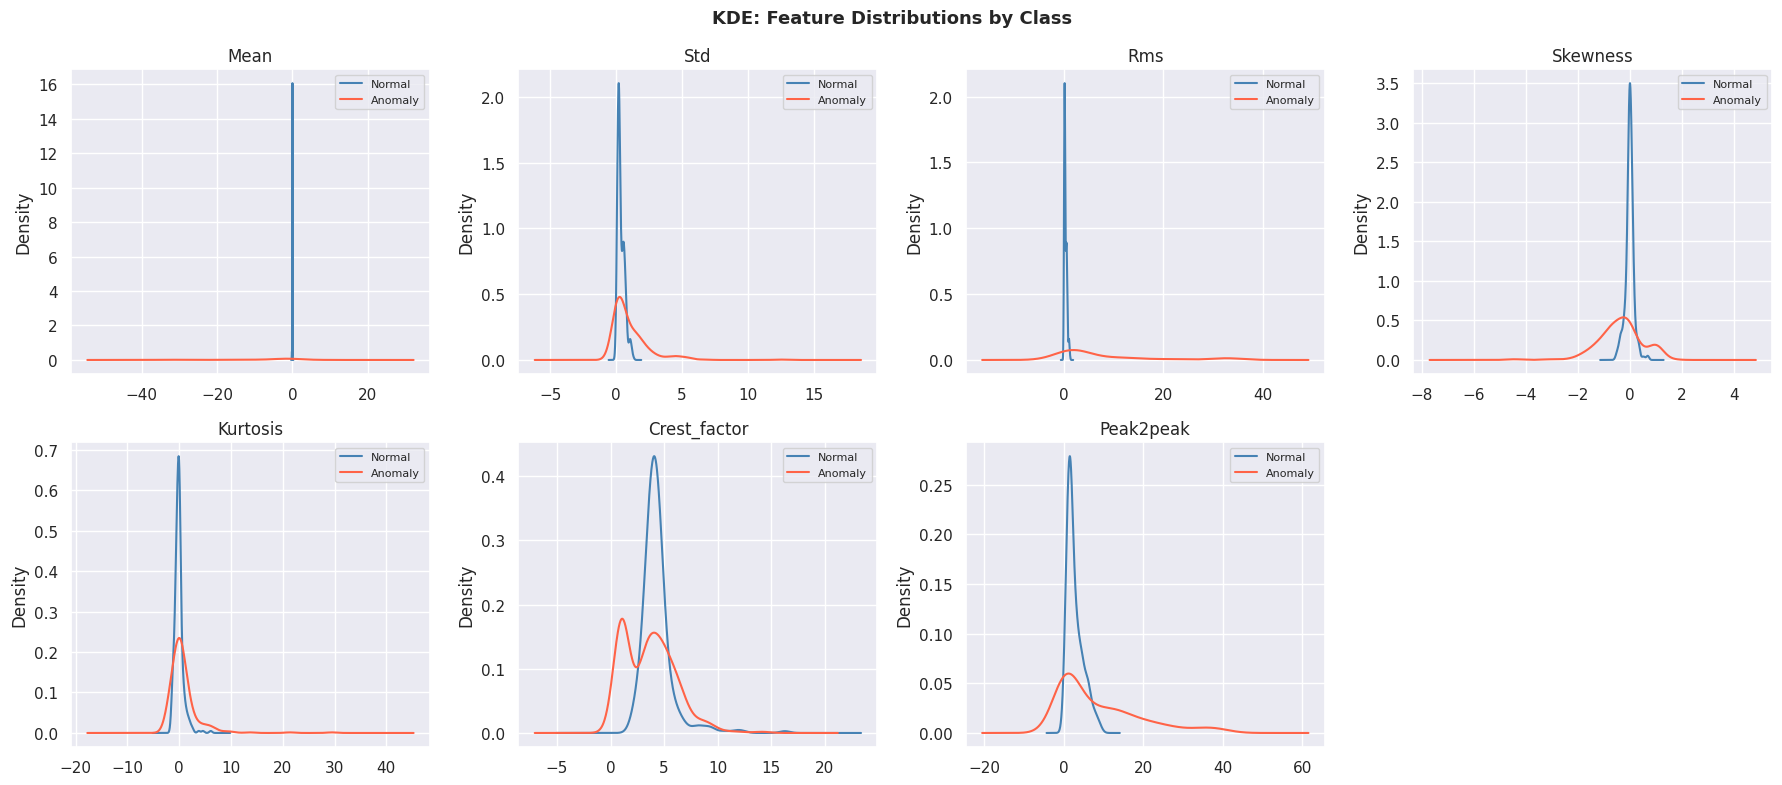

In [65]:
# --- KDE distributions for key features ---
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, feat in enumerate(features):
    normal_vals  = stats_test.loc[stats_test.label==0, feat]
    anomaly_vals = stats_test.loc[stats_test.label==1, feat]
    normal_vals.plot.kde(ax=axes[i], label='Normal', color='steelblue')
    anomaly_vals.plot.kde(ax=axes[i], label='Anomaly', color='tomato')
    axes[i].set_title(feat.capitalize())
    axes[i].legend(fontsize=8)
    axes[i].set_xlabel('')

axes[-1].axis('off')
plt.suptitle('KDE: Feature Distributions by Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 3  Time-Domain Analysis

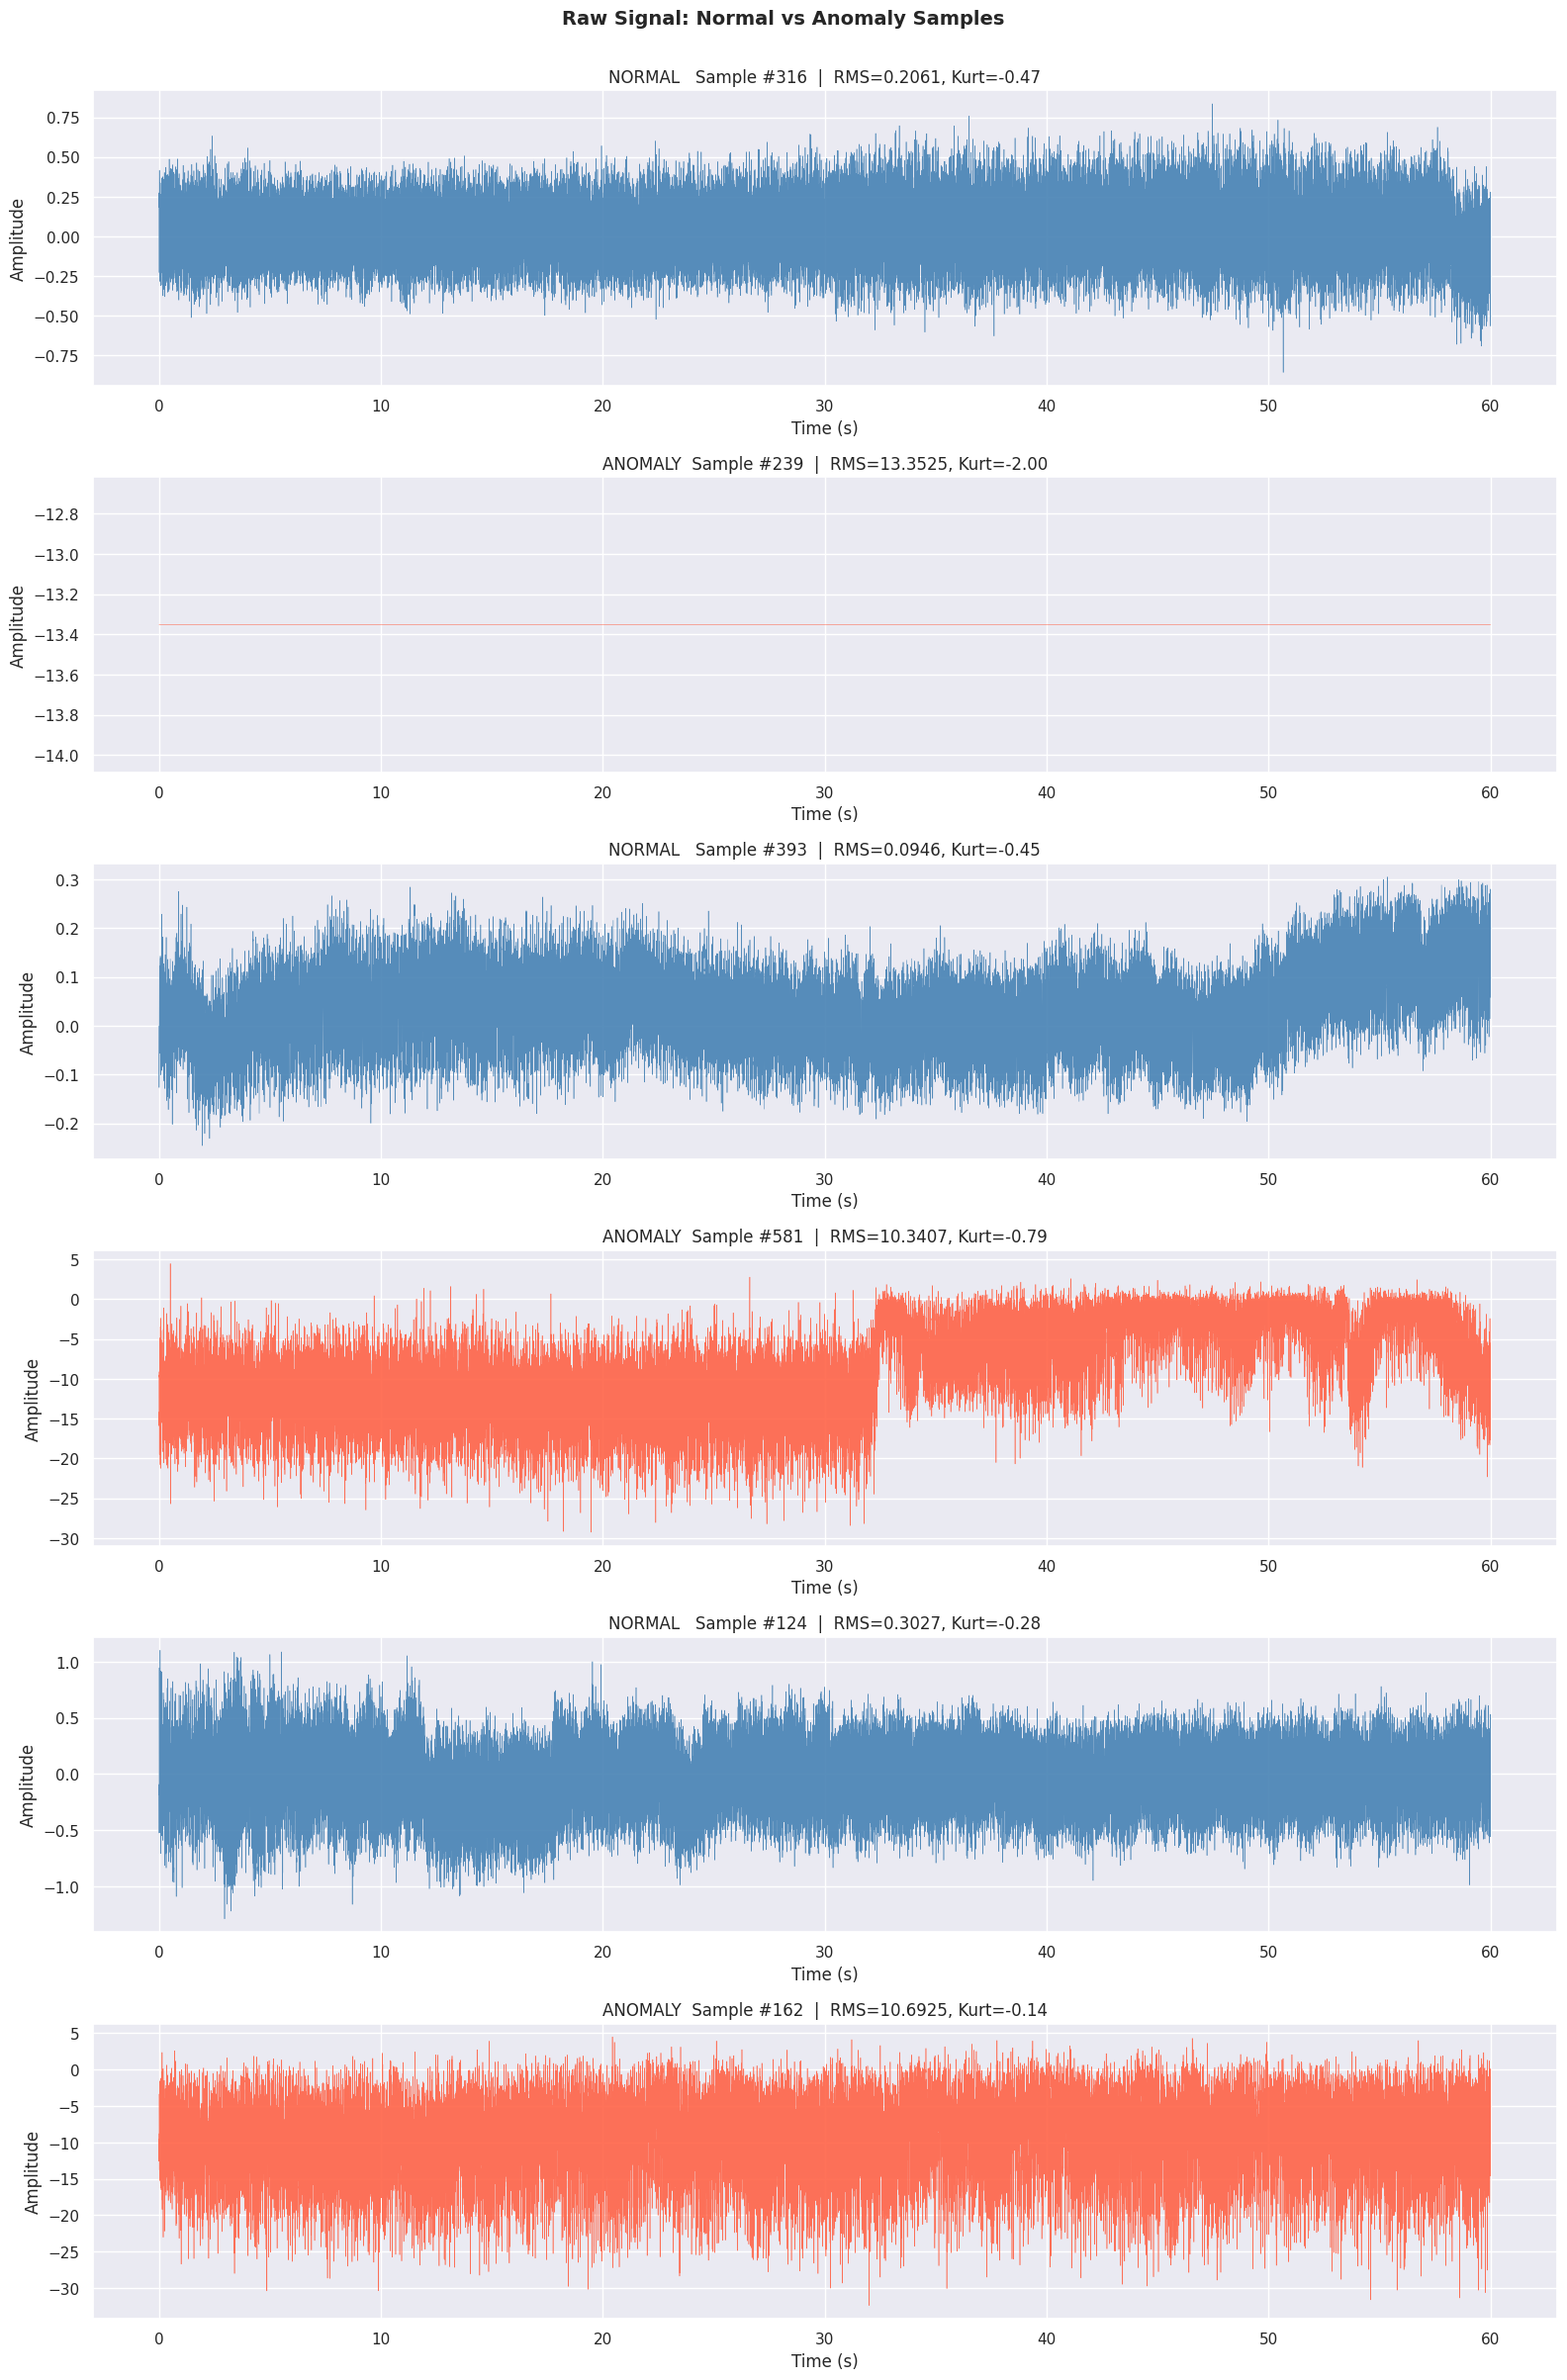

In [66]:
# SECTION 3: TIME-DOMAIN VISUALIZATION
time_axis = np.arange(N) / FS  # seconds

# Pick a few random normal and anomaly samples
np.random.seed(42)
normal_idx  = np.where(y_test == 0)[0]
anomaly_idx = np.where(y_test == 1)[0]

n_examples = min(3, len(normal_idx), len(anomaly_idx))
norm_samples = np.random.choice(normal_idx,  n_examples, replace=False)
anom_samples = np.random.choice(anomaly_idx, n_examples, replace=False)

fig, axes = plt.subplots(n_examples*2, 1, figsize=(16, 4*n_examples*2), sharex=False)

for i, (ni, ai) in enumerate(zip(norm_samples, anom_samples)):
    ax_n = axes[i*2]
    ax_a = axes[i*2 + 1]
    
    ax_n.plot(time_axis, X_test_raw[ni], color='steelblue', linewidth=0.4, alpha=0.9)
    ax_n.set_title(f'NORMAL   Sample #{ni}  |  RMS={stats_test.loc[ni,"rms"]:.4f}, Kurt={stats_test.loc[ni,"kurtosis"]:.2f}')
    ax_n.set_ylabel('Amplitude')
    ax_n.set_xlabel('Time (s)')
    
    ax_a.plot(time_axis, X_test_raw[ai], color='tomato', linewidth=0.4, alpha=0.9)
    ax_a.set_title(f'ANOMALY  Sample #{ai}  |  RMS={stats_test.loc[ai,"rms"]:.4f}, Kurt={stats_test.loc[ai,"kurtosis"]:.2f}')
    ax_a.set_ylabel('Amplitude')
    ax_a.set_xlabel('Time (s)')

plt.suptitle('Raw Signal: Normal vs Anomaly Samples', fontsize=14, fontweight='bold', y=1.002)
plt.tight_layout()
plt.show()

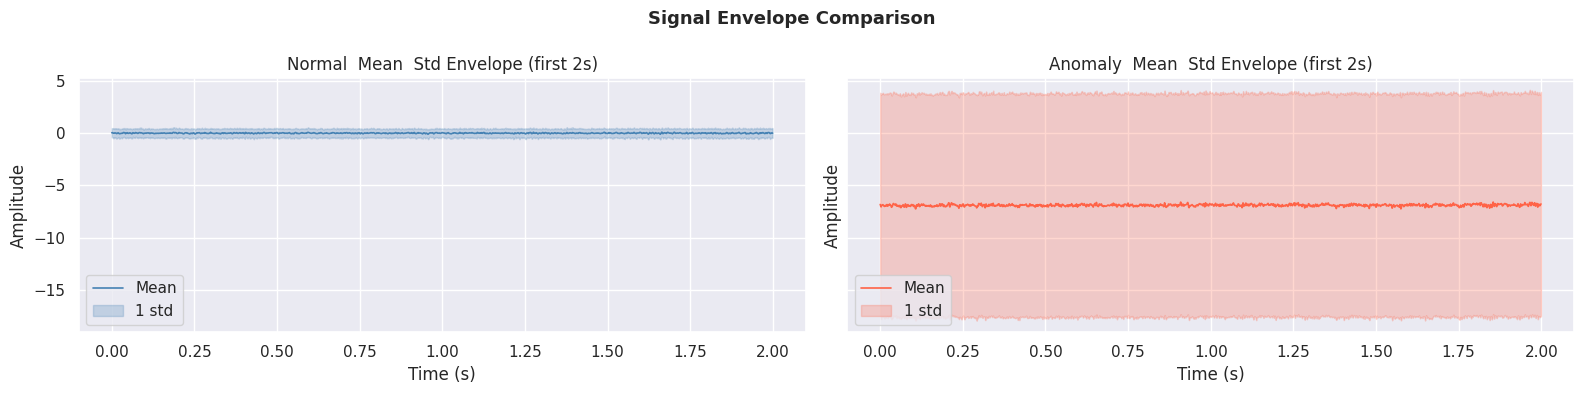

In [67]:
# --- Overlay: mean  std envelope across all normal vs anomaly ---
# Use first 2048 points for visibility
WIN = 2048
t_win = np.arange(WIN) / FS

normal_signals  = X_test_raw[normal_idx, :WIN]
anomaly_signals = X_test_raw[anomaly_idx, :WIN]

fig, axes = plt.subplots(1, 2, figsize=(16, 4), sharey=True)

for ax, signals, label, color in zip(
    axes,
    [normal_signals, anomaly_signals],
    ['Normal', 'Anomaly'],
    ['steelblue', 'tomato']
):
    mu  = signals.mean(axis=0)
    std = signals.std(axis=0)
    ax.plot(t_win, mu, color=color, linewidth=1.2, label='Mean')
    ax.fill_between(t_win, mu - std, mu + std, alpha=0.25, color=color, label='1 std')
    ax.set_title(f'{label}  Mean  Std Envelope (first 2s)')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Amplitude')
    ax.legend()

plt.suptitle('Signal Envelope Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4  Frequency Domain Analysis (FFT / PSD)

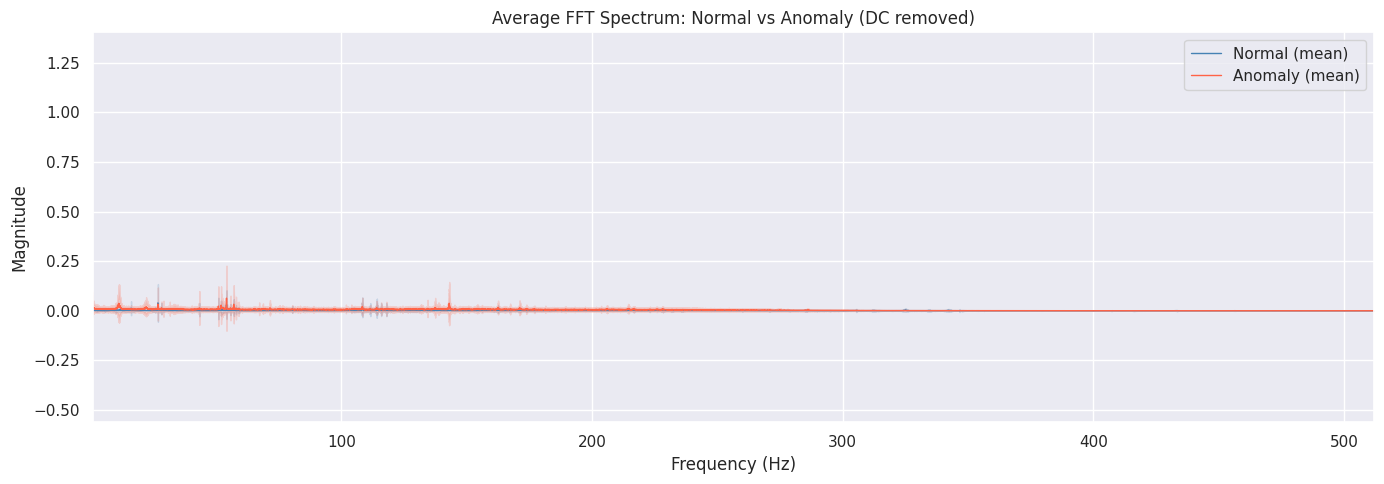

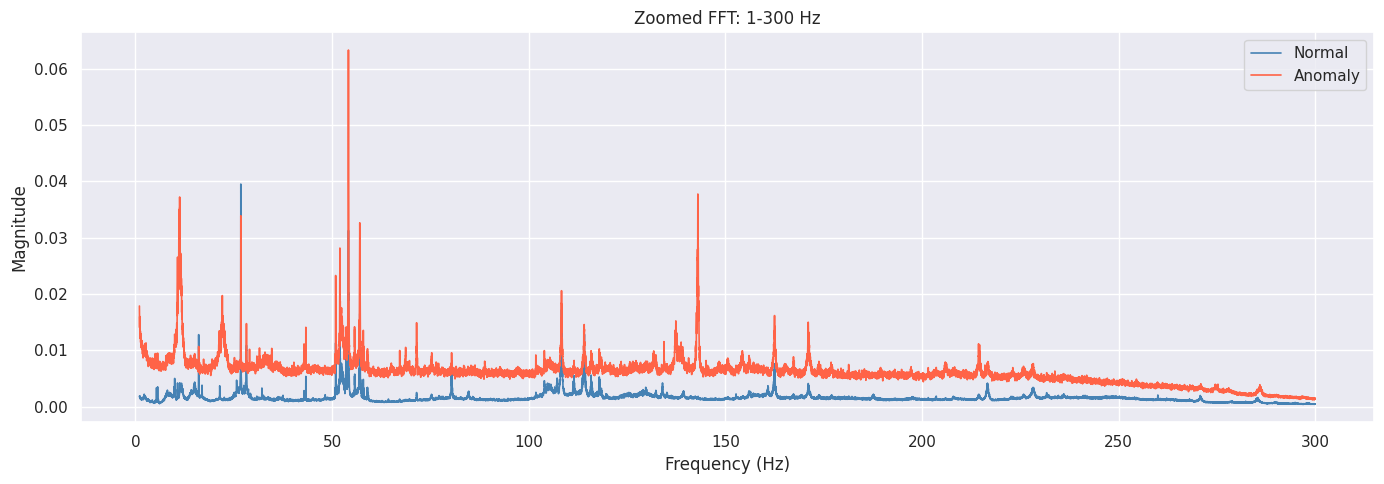

In [68]:
# SECTION 4: FREQUENCY DOMAIN
def compute_avg_fft(signals, fs=FS, remove_dc=True):
    """Average magnitude spectrum. remove_dc removes mean to eliminate 0Hz spike."""
    s = signals - signals.mean(axis=1, keepdims=True) if remove_dc else signals
    n = s.shape[1]
    freqs = fftfreq(n, d=1/fs)[:n//2]
    mags  = np.abs(fft(s, axis=1))[:, :n//2] * (2/n)
    return freqs, mags.mean(axis=0), mags.std(axis=0)

freqs_n, mag_n, std_n = compute_avg_fft(X_test_raw[normal_idx])
freqs_a, mag_a, std_a = compute_avg_fft(X_test_raw[anomaly_idx])


fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(freqs_n[1:], mag_n[1:], color="steelblue", linewidth=1, label="Normal (mean)")
ax.fill_between(freqs_n[1:], (mag_n-std_n)[1:], (mag_n+std_n)[1:], alpha=0.2, color="steelblue")
ax.plot(freqs_a[1:], mag_a[1:], color="tomato", linewidth=1, label="Anomaly (mean)")
ax.fill_between(freqs_a[1:], (mag_a-std_a)[1:], (mag_a+std_a)[1:], alpha=0.2, color="tomato")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Magnitude")
ax.set_title("Average FFT Spectrum: Normal vs Anomaly (DC removed)")
ax.legend()
ax.set_xlim(1, FS//2)
plt.tight_layout(); plt.show()


fig, ax = plt.subplots(figsize=(14, 5))
mask_n = (freqs_n > 1) & (freqs_n <= 300)
mask_a = (freqs_a > 1) & (freqs_a <= 300)
ax.plot(freqs_n[mask_n], mag_n[mask_n], color="steelblue", linewidth=1.2, label="Normal")
ax.plot(freqs_a[mask_a], mag_a[mask_a], color="tomato", linewidth=1.2, label="Anomaly")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Magnitude")
ax.set_title("Zoomed FFT: 1-300 Hz")
ax.legend()
plt.tight_layout(); plt.show()


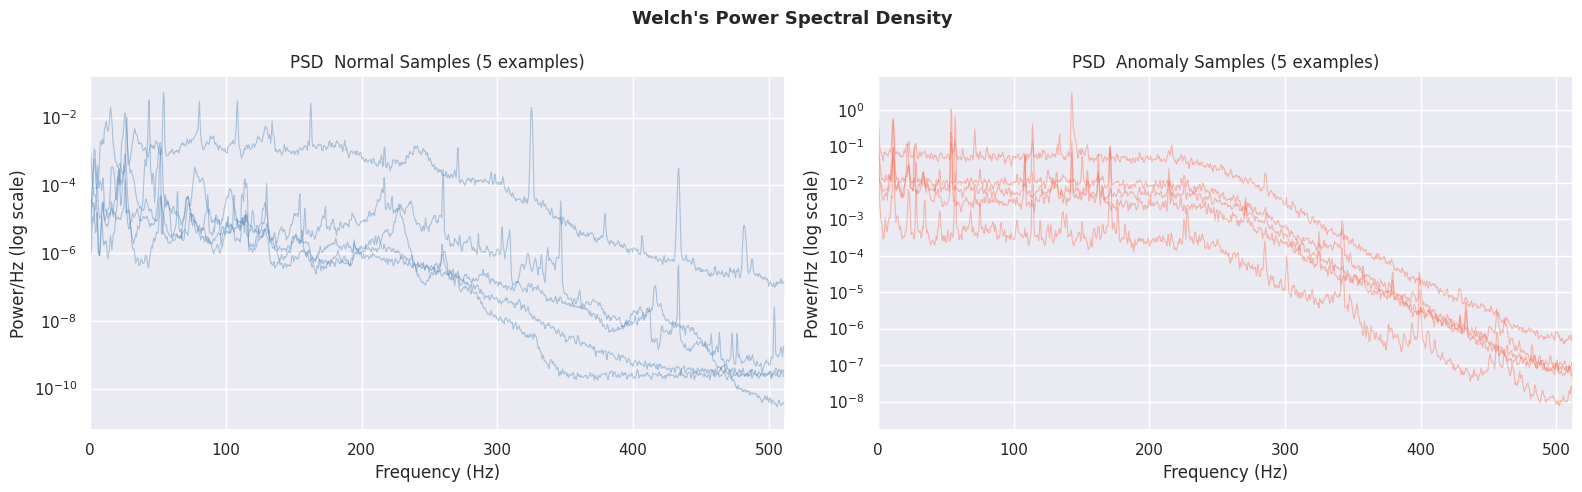

In [69]:
# --- Power Spectral Density (Welch's method) ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, idx, label, color in zip(
    axes,
    [normal_idx[:5], anomaly_idx[:5]],
    ['Normal', 'Anomaly'],
    ['steelblue', 'tomato']
):
    for i, si in enumerate(idx):
        f_psd, psd = signal.welch(X_test_raw[si], fs=FS, nperseg=2048)
        ax.semilogy(f_psd, psd, color=color, alpha=0.4, linewidth=0.8)
    ax.set_title(f'PSD  {label} Samples (5 examples)')
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('Power/Hz (log scale)')
    ax.set_xlim(0, FS//2)

plt.suptitle("Welch's Power Spectral Density", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

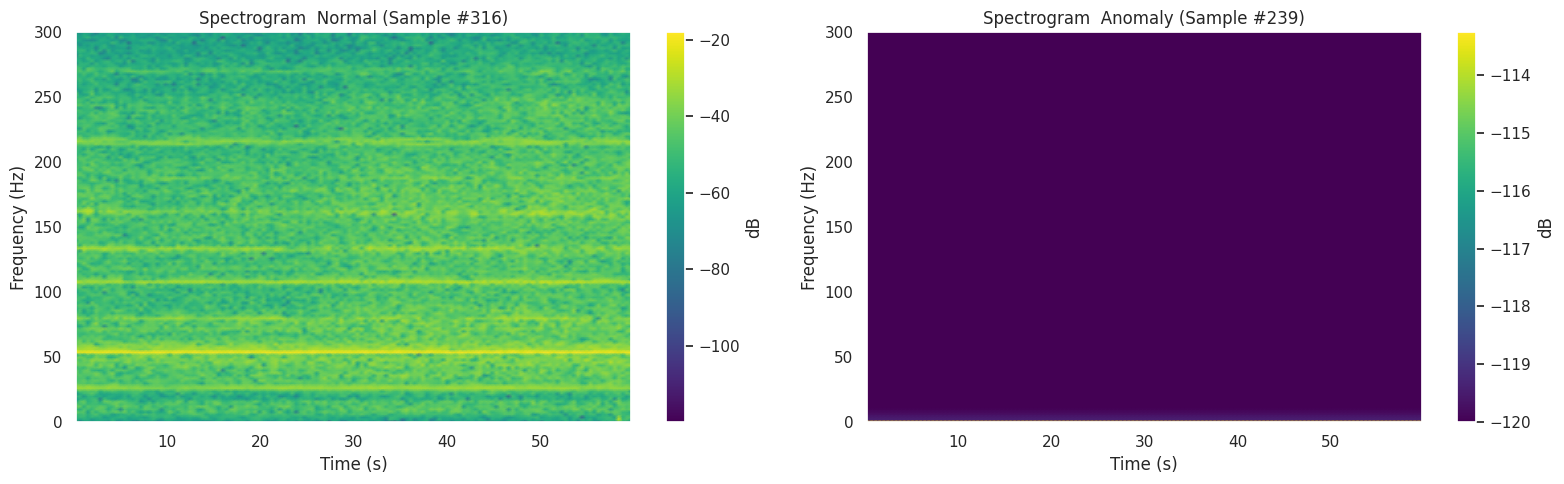

In [70]:
# --- Spectrogram comparison (one sample each) ---
n_sample = norm_samples[0]
a_sample = anom_samples[0]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, idx, title in zip(axes, [n_sample, a_sample], ['Normal', 'Anomaly']):
    f_sg, t_sg, Sxx = signal.spectrogram(X_test_raw[idx], fs=FS, nperseg=512)
    im = ax.pcolormesh(t_sg, f_sg, 10*np.log10(Sxx + 1e-12), shading='gouraud', cmap='viridis')
    ax.set_ylabel('Frequency (Hz)')
    ax.set_xlabel('Time (s)')
    ax.set_title(f'Spectrogram  {title} (Sample #{idx})')
    ax.set_ylim(0, 300)  # focus on relevant freq range
    plt.colorbar(im, ax=ax, label='dB')

plt.tight_layout()
plt.show()

## 5  Feature Correlation & Heatmaps

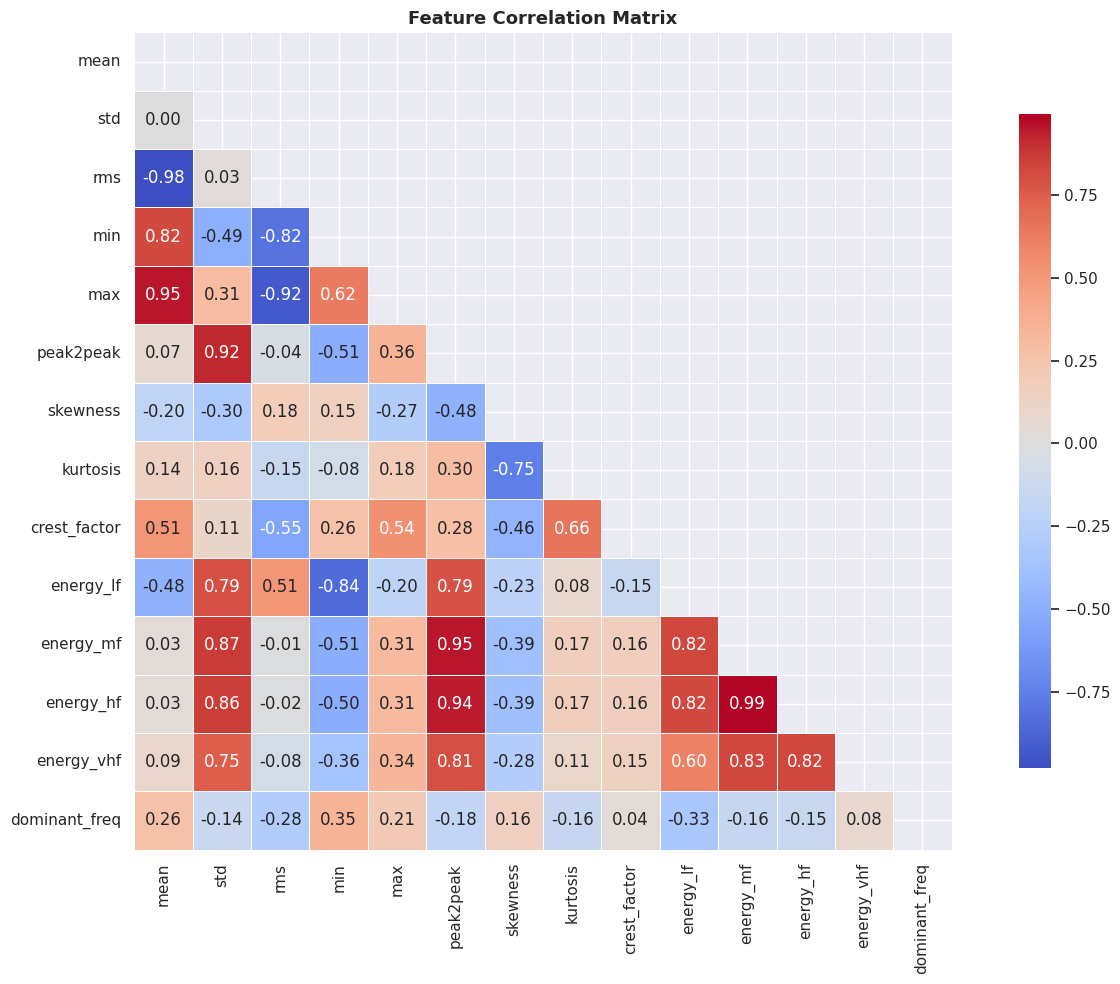

In [71]:
# SECTION 5: FEATURE CORRELATION ANALYSIS

# --- Extract frequency-domain features per sample ---
def extract_freq_features(X, fs=FS, bands=None):
    """Band energy + dominant frequency features."""
    if bands is None:
        # Hz bands relevant to helicopter vibrations
        bands = [(0,50,'lf'), (50,150,'mf'), (150,300,'hf'), (300,512,'vhf')]
    n = X.shape[1]
    freqs = fftfreq(n, d=1/fs)[:n//2]
    mags  = np.abs(fft(X, axis=1))[:, :n//2]
    
    result = {}
    for lo, hi, name in bands:
        mask = (freqs >= lo) & (freqs < hi)
        result[f'energy_{name}'] = mags[:, mask].sum(axis=1)
    result['dominant_freq'] = freqs[mags.argmax(axis=1)]
    return pd.DataFrame(result)

freq_feats = extract_freq_features(X_test_raw)
all_feats  = pd.concat([stats_test.drop('label', axis=1), freq_feats], axis=1)
all_feats['label'] = y_test

# Correlation heatmap
fig, ax = plt.subplots(figsize=(14, 10))
corr = all_feats.drop('label', axis=1).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, ax=ax, cbar_kws={'shrink':0.8})
ax.set_title('Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

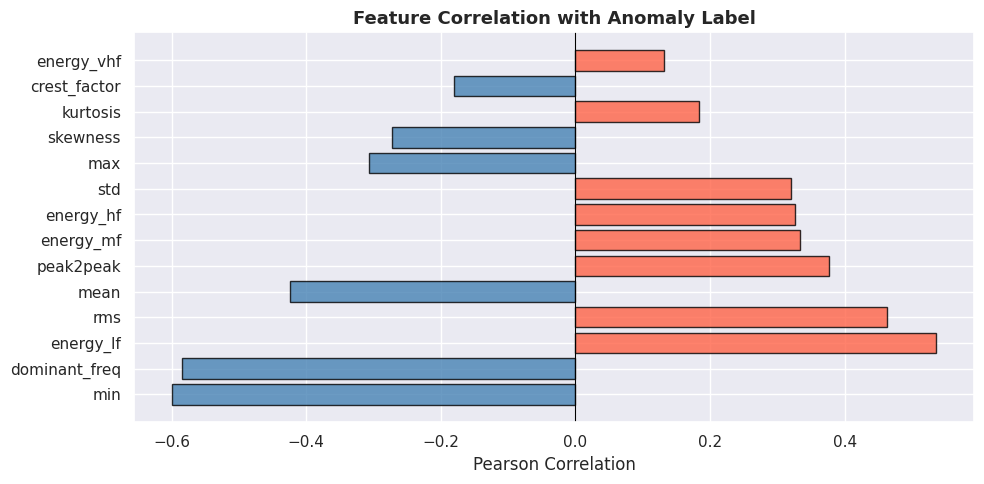

Top features correlated with anomaly label:
min             -0.598683
dominant_freq   -0.585170
energy_lf        0.535336
rms              0.462264
mean            -0.423964
peak2peak        0.377161
energy_mf        0.333931
energy_hf        0.326552


In [72]:
# --- Correlation with label ---
label_corr = all_feats.corr()['label'].drop('label').sort_values(key=abs, ascending=False)

plt.figure(figsize=(10, 5))
colors = ['tomato' if v > 0 else 'steelblue' for v in label_corr.values]
plt.barh(label_corr.index, label_corr.values, color=colors, edgecolor='black', alpha=0.8)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Feature Correlation with Anomaly Label', fontsize=13, fontweight='bold')
plt.xlabel('Pearson Correlation')
plt.tight_layout()
plt.show()

print("Top features correlated with anomaly label:")
print(label_corr.head(8).to_string())

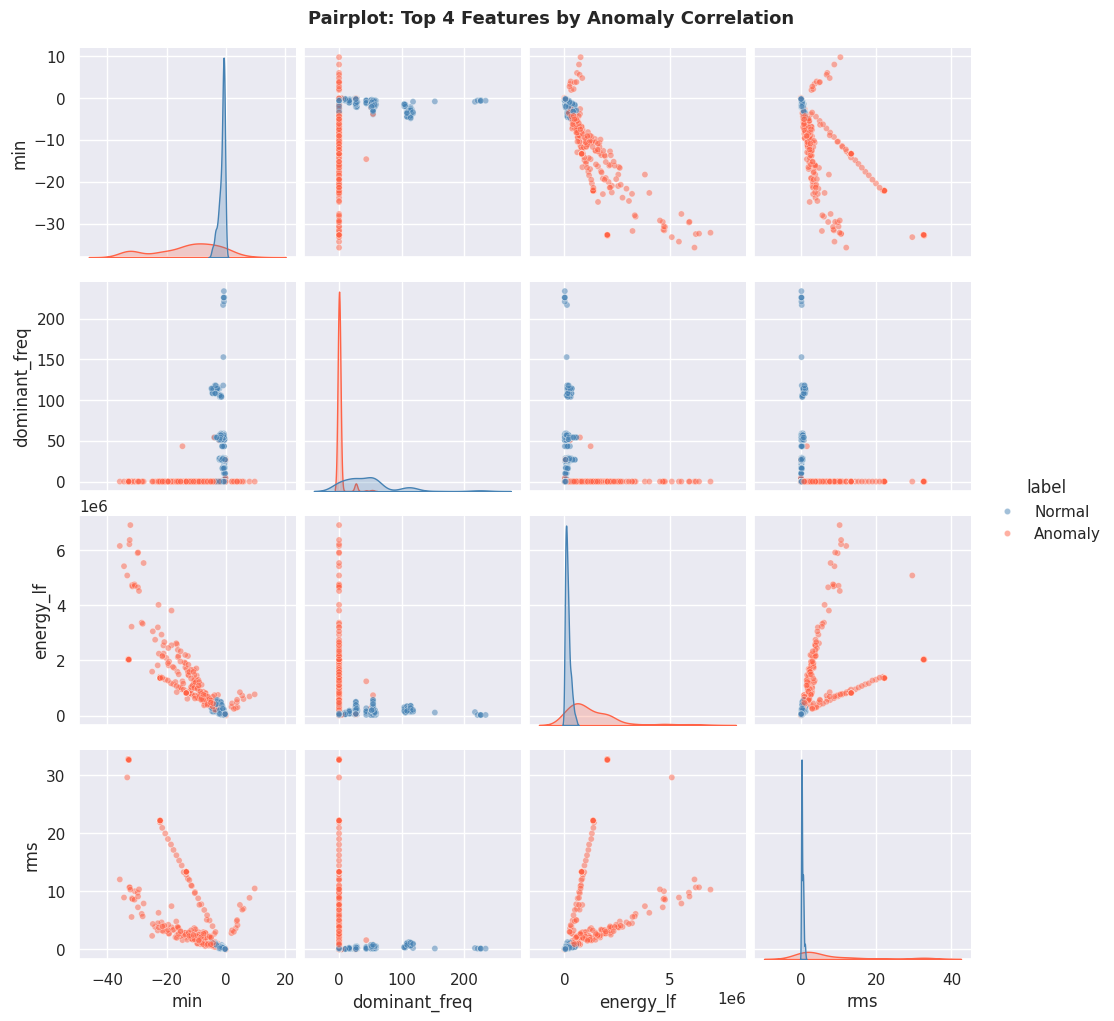

In [73]:
# --- Pairplot of top 4 most correlated features ---
top_feats = label_corr.abs().nlargest(4).index.tolist()
pair_df = all_feats[top_feats + ['label']].copy()
pair_df['label'] = pair_df['label'].map({0: 'Normal', 1: 'Anomaly'})

g = sns.pairplot(pair_df, hue='label', palette={'Normal':'steelblue','Anomaly':'tomato'},
                 plot_kws={'alpha':0.5, 's':20}, diag_kind='kde')
g.fig.suptitle('Pairplot: Top 4 Features by Anomaly Correlation', y=1.02, fontsize=13, fontweight='bold')
plt.show()

## 6  Train vs Test Distribution Shift

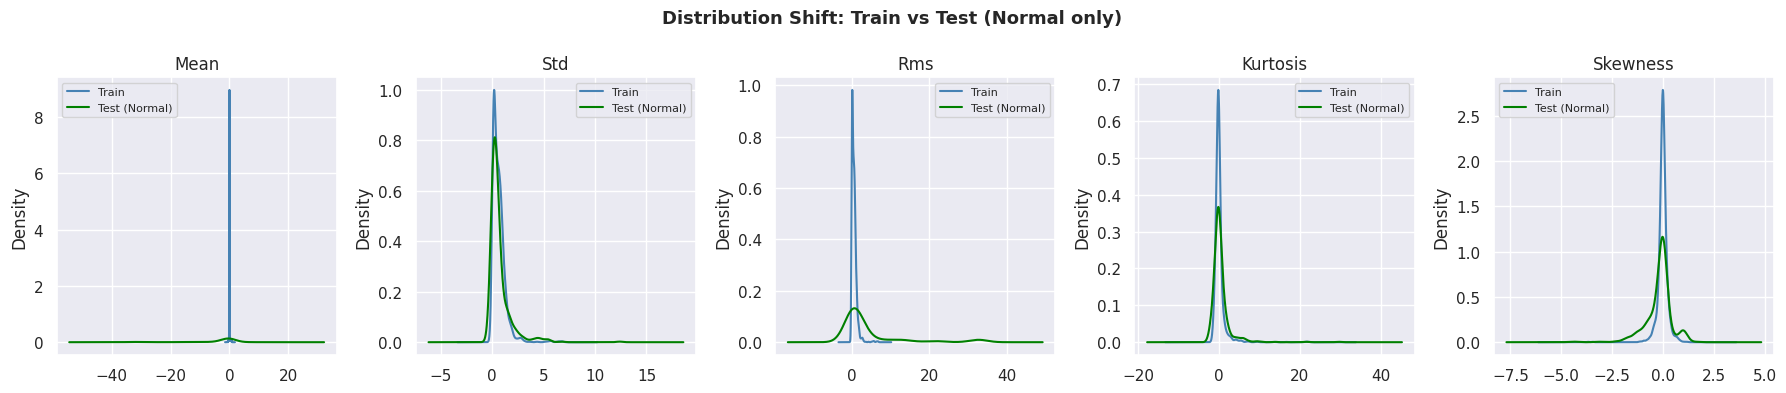

Kolmogorov-Smirnov Test: Train vs Test-Normal
---------------------------------------------
mean           : KS=0.4127, p=0.0000   SHIFT
std            : KS=0.1554, p=0.0000   SHIFT
rms            : KS=0.3027, p=0.0000   SHIFT
kurtosis       : KS=nan, p=nan  OK
skewness       : KS=nan, p=nan  OK


In [74]:
# SECTION 6: TRAIN vs TEST DISTRIBUTION SHIFT
# Important: train has NO anomalies (assumed normal-only baseline)

stats_train['split'] = 'Train'
stats_test_plot = stats_test.drop('label', axis=1).copy()
stats_test_plot['split'] = 'Test (Normal)'

combined = pd.concat([stats_train, stats_test_plot], ignore_index=True)

feats_to_compare = ['mean', 'std', 'rms', 'kurtosis', 'skewness']
fig, axes = plt.subplots(1, len(feats_to_compare), figsize=(18, 4))

for ax, feat in zip(axes, feats_to_compare):
    for split, color in [('Train','steelblue'), ('Test (Normal)','green')]:
        subset = combined[combined.split == split][feat]
        subset.plot.kde(ax=ax, label=split, color=color)
    ax.set_title(feat.capitalize())
    ax.legend(fontsize=8)
    ax.set_xlabel('')

plt.suptitle('Distribution Shift: Train vs Test (Normal only)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# KS-test for each feature
print("Kolmogorov-Smirnov Test: Train vs Test-Normal")
print("-" * 45)
for feat in feats_to_compare:
    ks_stat, p_val = stats.ks_2samp(
        stats_train[feat],
        stats_test_plot[feat]
    )
    sig = ' SHIFT' if p_val < 0.05 else 'OK'
    print(f"{feat:15s}: KS={ks_stat:.4f}, p={p_val:.4f}  {sig}")

## 7  Summary  Key Findings

In [75]:
# SECTION 7: AUTOMATED SUMMARY
normal_stats  = stats_test[stats_test.label == 0]
anomaly_stats = stats_test[stats_test.label == 1]

print("=" * 55)
print(" HELICOPTER ACCELEROMETER  EDA SUMMARY")
print("=" * 55)

print(f"\n Dataset Size")
print(f"  Train samples  : {X_train_raw.shape[0]:,}")
print(f"  Test  samples  : {X_test_raw.shape[0]:,}")
print(f"  Signal length  : {N:,} pts ({DURATION}s @ {FS}Hz)")
print(f"  Anomaly rate   : {y_test.mean()*100:.1f}% ({y_test.sum()} anomalies)")

print(f"\n Statistical Differences (Normal vs Anomaly mean)")
for feat in ['rms', 'kurtosis', 'crest_factor', 'std', 'peak2peak']:
    n_val = normal_stats[feat].mean()
    a_val = anomaly_stats[feat].mean()
    pct   = (a_val - n_val) / (abs(n_val) + 1e-9) * 100
    arrow = '' if pct > 0 else ''
    print(f"  {feat:15s}: Normal={n_val:.4f}  Anomaly={a_val:.4f}  {arrow}{abs(pct):.1f}%")

print(f"\n Top features discriminating anomalies:")
for feat, val in label_corr.abs().nlargest(5).items():
    print(f"  {feat:20s}: |corr| = {val:.3f}")

print("\n EDA Complete")

 HELICOPTER ACCELEROMETER  EDA SUMMARY

 Dataset Size
  Train samples  : 1,677
  Test  samples  : 594
  Signal length  : 61,440 pts (60s @ 1024Hz)
  Anomaly rate   : 50.0% (297 anomalies)

 Statistical Differences (Normal vs Anomaly mean)
  rms            : Normal=0.3588  Anomaly=7.8612  2090.8%
  kurtosis       : Normal=-0.0577  Anomaly=0.7706  1435.0%
  crest_factor   : Normal=4.3585  Anomaly=3.6302  16.7%
  std            : Normal=0.3571  Anomaly=1.0444  192.5%
  peak2peak      : Normal=2.7759  Anomaly=8.8597  219.2%

 Top features discriminating anomalies:
  min                 : |corr| = 0.599
  dominant_freq       : |corr| = 0.585
  energy_lf           : |corr| = 0.535
  rms                 : |corr| = 0.462
  mean                : |corr| = 0.424

 EDA Complete
